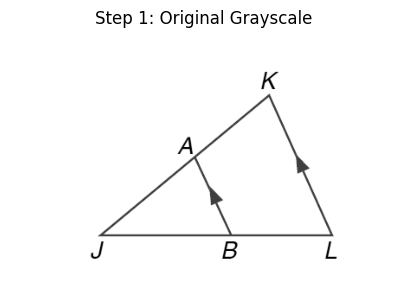

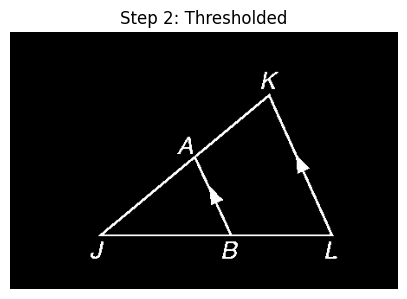

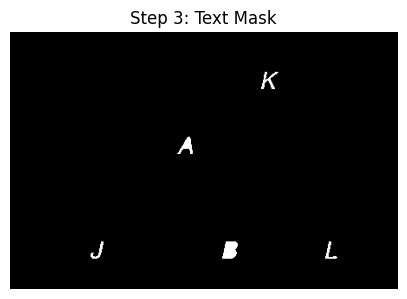

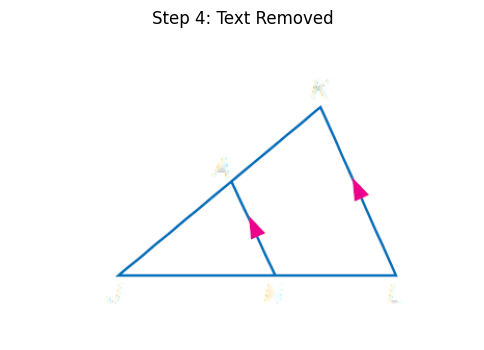

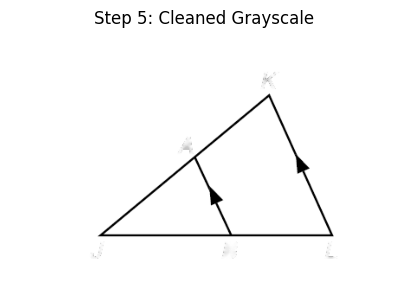

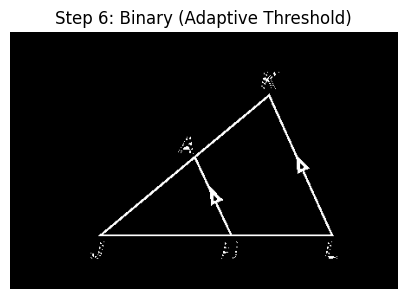

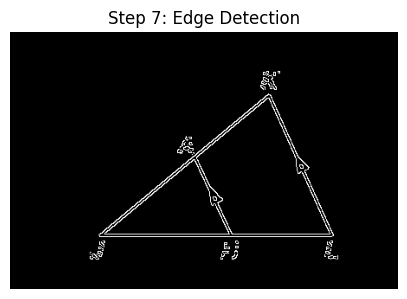

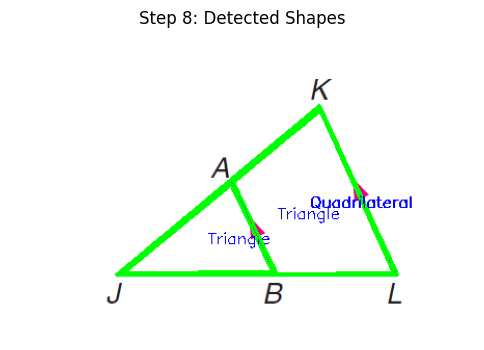

Detected Shapes: ['Triangle', 'Triangle', 'Triangle', 'Triangle', 'Quadrilateral', 'Quadrilateral']
No inscribed shapes found.


In [ ]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

def preprocess(path):
    # Step 1: Read and convert to grayscale
    image = cv2.imread(path)
    if image is None:
        raise FileNotFoundError(f"Image not found at {path}")
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    plt.figure(figsize=(5, 5))
    plt.imshow(gray, cmap='gray')
    plt.title("Step 1: Original Grayscale")
    plt.axis("off")
    plt.savefig("step1_grayscale.png")
    plt.show()
    plt.close()

    # Step 2: Adaptive Thresholding
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 15, 9)
    plt.figure(figsize=(5, 5))
    plt.imshow(thresh, cmap='gray')
    plt.title("Step 2: Thresholded")
    plt.axis("off")
    plt.savefig("step2_thresholded.png")
    plt.show()
    plt.close()

    return image, gray, thresh

def detectedTextRegion(thresh):
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(thresh)

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        area = cv2.contourArea(cnt)
        aspectRatio = w / float(h)

        # Filter for small area and reasonable size and aspect ratio
        if 10 < area < 3000 and 0.2 < aspectRatio < 10:
            cv2.drawContours(mask, [cnt], -1, 255, -1)

    plt.figure(figsize=(5, 5))
    plt.imshow(mask, cmap='gray')
    plt.title("Step 3: Text Mask")
    plt.axis("off")
    plt.savefig("step3_textmask.png")
    plt.show()
    plt.close()

    return mask

def removeText(image, mask):
    cleaned = cv2.inpaint(image, mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(cleaned, cv2.COLOR_BGR2RGB))
    plt.title("Step 4: Text Removed")
    plt.axis("off")
    plt.savefig("step4_text_removed.png")
    plt.show()
    plt.close()
    return cleaned

def preprocessingForContours(cleanedText):
    # Step 5: Convert cleaned image to grayscale
    gray = cv2.cvtColor(cleanedText, cv2.COLOR_BGR2GRAY)
    plt.figure(figsize=(5, 5))
    plt.imshow(gray, cmap='gray')
    plt.title("Step 5: Cleaned Grayscale")
    plt.axis("off")
    plt.savefig("step5_cleaned_grayscale.png")
    plt.show()
    plt.close()

    # Step 6: Binary thresholding
    binary = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 9, 3)
    plt.figure(figsize=(5, 5))
    plt.imshow(binary, cmap='gray')
    plt.title("Step 6: Binary (Adaptive Threshold)")
    plt.axis("off")
    plt.savefig("step6_binary.png")
    plt.show()
    plt.close()

    return binary

def detectContoursAndShapes(binary, original_image):
    # Step 7: Apply Gaussian blur and Canny edge detection
    blurred = cv2.GaussianBlur(binary, (5, 5), 1)
    edges = cv2.Canny(blurred, 50, 150)

    plt.figure(figsize=(5, 5))
    plt.imshow(edges, cmap='gray')
    plt.title("Step 7: Edge Detection")
    plt.axis("off")
    plt.savefig("step7_edges.png")
    plt.show()
    plt.close()

    # Find contours and hierarchy
    contours, hierarchy = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    if not contours or hierarchy is None:
        print("No contours or hierarchy found!")
        return

    hierarchy = hierarchy[0]
    shapes = []

    # Loop through contours
    for i, cnt in enumerate(contours):
        epsilon = 0.02 * cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, epsilon, True)
        vertices = len(approx)

        M = cv2.moments(cnt)
        if M['m00'] != 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
        else:
            cx, cy = 0, 0
        center = (cx, cy)

        area = cv2.contourArea(cnt)
        if area < 200:  # Filter out small contours
            continue

        side_lengths = []
        for j in range(vertices):
            p1 = approx[j][0]
            p2 = approx[(j + 1) % vertices][0]
            dist = math.hypot(p2[0] - p1[0], p2[1] - p1[1])
            side_lengths.append(dist)

        angles = []
        for j in range(vertices):
            p0 = approx[j - 1][0]
            p1 = approx[j][0]
            p2 = approx[(j + 1) % vertices][0]

            v1 = (p0[0] - p1[0], p0[1] - p1[1])
            v2 = (p2[0] - p1[0], p2[1] - p1[1])

            dot_prod = v1[0] * v2[0] + v1[1] * v2[1]
            mag1 = math.hypot(v1[0], v1[1])
            mag2 = math.hypot(v2[0], v2[1])

            if mag1 == 0 or mag2 == 0:
                angle = 0
            else:
                cos_theta = dot_prod / (mag1 * mag2)
                cos_theta = max(min(cos_theta, 1), -1)
                angle = math.acos(cos_theta) * 180 / math.pi
            angles.append(angle)

        shape = "Unknown"
        if vertices == 3:
            shape = "Triangle"
        elif vertices == 4:
            sides_equal = all(abs(side_lengths[k] - side_lengths[0]) < 10 for k in range(1, 4))
            angles_close_90 = all(abs(a - 90) < 15 for a in angles)
            if sides_equal and angles_close_90:
                shape = "Square"
            elif angles_close_90:
                shape = "Rectangle"
            else:
                shape = "Quadrilateral"
        elif vertices > 4:
            circularity = 4 * math.pi * area / (cv2.arcLength(cnt, True) ** 2) if cv2.arcLength(cnt, True) != 0 else 0
            shape = "Circle" if circularity > 0.8 else f"{vertices}-gon"

        shapes.append({
            'index': i,
            'shape': shape,
            'center': center,
            'area': area,
            'parent': hierarchy[i][3],
            'contour': approx,
            'sides': side_lengths,
            'angles': angles
        })

    # Detect inscribed shapes
    inscribed_shapes = []
    for s in shapes:
        if s['parent'] != -1:
            parent = next((p for p in shapes if p['index'] == s['parent']), None)
            if parent:
                dx = abs(s['center'][0] - parent['center'][0])
                dy = abs(s['center'][1] - parent['center'][1])
                area_ratio = s['area'] / parent['area'] if parent['area'] != 0 else 0
                if dx < 20 and dy < 20 and 0.3 < area_ratio < 0.7:
                    inscribed_shapes.append((s['shape'], parent['shape'], s['index'], parent['index']))

    # Step 8: Visualize contours
    contour_image = original_image.copy()
    for s in shapes:
        cv2.drawContours(contour_image, [s['contour']], -1, (0, 255, 0), 2)
        cv2.putText(contour_image, s['shape'], s['center'], cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB))
    plt.title("Step 8: Detected Shapes")
    plt.axis("off")
    plt.savefig("step8_detected_shapes.png")
    plt.show()
    plt.close()

    # Print results
    print("Detected Shapes:", [s['shape'] for s in shapes])
    if inscribed_shapes:
        print("Inscribed Shapes Found:", [(s[0], s[1], s[2], s[3]) for s in inscribed_shapes])
    else:
        print("No inscribed shapes found.")

def process_image(path):
    # Preprocessing pipeline
    image, gray, thresh = preprocess(path)
    text_mask = detectedTextRegion(thresh)
    cleaned_text = removeText(image, text_mask)
    binary = preprocessingForContours(cleaned_text)

    # Contour detection and shape analysis
    detectContoursAndShapes(binary, image)

if __name__ == "__main__":
    #path = r"C:\Users\ashut\Documents\GitHub\ProjectMajor\IMGTEST\003.png"
    path = r"C:\Users\ashut\Downloads\Geometry3k\val\2131\img_diagram.png"



    process_image(path)
